# From Superposition to Sparse Interpretable Codes — a runnable replication

An implementation of the three-step framework of **Klindt, O'Neill, Reizinger, Maurer & Miolane,
*A unifying framework from neural superposition to sparse interpretable codes*, Nature Machine
Intelligence 8:1025–1037 (2026)**, applied end to end to open-source models on a single Colab GPU.

The paper's pipeline (its Fig. 1) has three steps, and each makes a claim we can actually test:

| Step | Claim | How we test it | Part |
|---|---|---|---|
| 0 | Representations are **additive**: Ψ(A and B) = Ψ(A) + Ψ(B) | controlled compositional images through CLIP, with controls | I |
| 1 | **Identifiability**: a net trained with cross-entropy inverts the generative model *up to a linear map* (Theorem 1) | synthetic world with known latents `z`; test whether `h = f∘g` is linear | II |
| 2 | **Compressed sensing**: sparse codes are recoverable when `M = O(K log N/K)` (eq. 6) | synthetic recovery, phase diagram vs the predicted boundary | III |
| 3 | **Quantitative interpretability**: latents are more interpretable than mixtures of them (eq. 9) | automated word-intrusion on real SAE features vs neurons vs mixtures | IV |

### Why steps 1 and 2 must be synthetic

This is the central design decision. The paper's own argument is that *we never know the true latent
variables* — which is exactly why step 3 (interpretability metrics) exists as a proxy. So identifiability
and recovery claims are **not directly testable on a real LLM**: there is no ground-truth `z` to compare
against. Testing them requires a world where we construct `g` and `z` ourselves. Parts II and III therefore
build that world; Parts I and IV run on real open-source models, where the paper's claims *are* checkable.
Conflating the two is the most common way this literature goes wrong.

### Models

| Model | Params | Used for |
|---|---|---|
| `openai/clip-vit-base-patch16` | 150M | Part I: additivity and analogy in a real vision encoder |
| `gpt2` + `gpt2-small-res-jb` SAEs (SAELens) | 124M | Part IV: interpretability of SAE features vs neurons |
| `sentence-transformers/all-MiniLM-L6-v2` | 22M | Part IV: automated odd-one-out judge |
| synthetic MLPs | — | Parts II, III: ground-truth latents |

> **Runtime:** T4 is plenty; most of the compute is the synthetic experiments, which are small. Full run
> ≈ 25–40 minutes.

> **Provenance.** Every number quoted in the commentary below is a real output of this notebook, executed
> end to end on a Colab T4. Where a result contradicts what the framework predicts, it is reported as such
> rather than smoothed over — two of the paper's claims did not replicate here, and one replicated only
> weakly. Those are the most informative parts of the run.

### Summary of what replicated

| Claim | Result |
|---|---|
| Compressed sensing bound `M = O(K log N/K)` | **Held**, with a constant of ~1.0–1.5 |
| Sparse coding recovers the dictionary | **Held** (0.984 at the right sparsity) |
| Theorem 1 linear identifiability | **Held**, but only when the objective is still constraining |
| SAE features more interpretable than neurons | **Held** (0.617 vs 0.436) |
| CLIP representations are additive | **Weak** — matched 0.894 vs mismatched control 0.816 |
| MLP encoders close the amortisation gap | **Did not replicate** (0.263 vs 0.935 for a linear SAE) |
| Eq. (9): mixing reduces interpretability | **Not detected** — flat within noise |

## 0. Setup

In [ ]:
%pip install -q transformers sae_lens sentence-transformers plotly scikit-learn pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.7/334.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os, math, time, random, itertools, gc
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import plotly.express as px, plotly.graph_objects as go, plotly.io as pio
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

try:
    import google.colab  # noqa
    pio.renderers.default = "colab"
except ImportError:
    pass

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0); random.seed(0)
print("device:", DEVICE)

def purge():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

device: cuda


In [ ]:
# ---- metrics used throughout ----
def mcc(Z_true, Z_hat):
    # Mean Correlation Coefficient up to PERMUTATION - the paper's guarantee is recovery
    # up to permutation and scaling (z_hat = diag(S) P z), so the metric must be invariant to both.
    A = Z_true - Z_true.mean(0); B = Z_hat - Z_hat.mean(0)
    A = A / (A.std(0) + 1e-8); B = B / (B.std(0) + 1e-8)
    C = np.nan_to_num(np.abs(A.T @ B) / len(A))
    r, c = linear_sum_assignment(-C)
    return float(C[r, c].mean())

def dict_recovery(Phi, Theta):
    # how well the learned dictionary columns match the true ones (up to permutation and sign)
    A = Phi / (np.linalg.norm(Phi, axis=0, keepdims=True) + 1e-9)
    B = Theta / (np.linalg.norm(Theta, axis=0, keepdims=True) + 1e-9)
    C = np.abs(A.T @ B)
    r, c = linear_sum_assignment(-C)
    return float(C[r, c].mean())

def linear_r2(X, Y):
    Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.3, random_state=0)
    P = Ridge(alpha=1e-3).fit(Xtr, Ytr).predict(Xte)
    return float(1 - ((Yte - P) ** 2).sum() / ((Yte - Yte.mean(0)) ** 2).sum())

def mlp_r2(X, Y, hidden=256, steps=800, seed=0):
    # nonlinear upper bound: if linear_r2 ~= mlp_r2 the mapping really is linear
    torch.manual_seed(seed)
    Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.3, random_state=0)
    xtr = torch.tensor(Xtr, dtype=torch.float32); ytr = torch.tensor(Ytr, dtype=torch.float32)
    xte = torch.tensor(Xte, dtype=torch.float32); yte = torch.tensor(Yte, dtype=torch.float32)
    net = nn.Sequential(nn.Linear(X.shape[1], hidden), nn.ReLU(),
                        nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, Y.shape[1]))
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    for _ in range(steps):
        opt.zero_grad(); F.mse_loss(net(xtr), ytr).backward(); opt.step()
    with torch.no_grad(): P = net(xte)
    return float(1 - ((yte - P) ** 2).sum() / ((yte - yte.mean(0)) ** 2).sum())

def cos(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9))

## Part I — Is the representation really additive? (the superposition principle)

The paper's Fig. 2 shows that for a ViT, `f∘g(elephant) + f∘g(pink ball) ≈ f∘g(elephant and pink ball)`,
reporting cosine similarity 0.96, and an analogy version at 0.92. Smolensky's definition (their eq. 4) is
exactly this additivity property.

We reproduce it with **procedurally generated stimuli** rather than GPT-4 images. This is a deliberate
change: controlled colour × shape stimuli let us build the exact minimal pairs the claim needs, and they
are reproducible by anyone running the notebook.

**Two controls the headline number needs.** A raw cosine between `E(A and B)` and `E(A) + E(B)` is
inflated, because every embedding of these images shares a large common component (background, image
statistics, the "this is a simple shape image" direction). Adding two embeddings doubles that shared
component, and cosine similarity rewards it. So we also report:

1. **Background-subtracted** additivity, using the embedding of the empty scene as the origin;
2. a **mismatched control**, `cos(E(A and B), E(A') + E(B'))` for objects that are *not* in the image.

If the mismatched control is nearly as high as the real one, the raw number was measuring the shared
component, not compositional structure.

### The error, and three more it was hiding

**The reported failure: `'BaseModelOutputWithPooling' object has no attribute 'float'`.**
Transformers v5 changed `get_image_features` / `get_text_features` to return a dataclass instead of a
plain tensor; the projected embedding that v4 returned is now in `.pooler_output`. `embed` now unwraps
both shapes, and asserts the result's width equals `projection_dim` — because the failure mode to fear
here is not a crash but silently grabbing `last_hidden_state` and computing the whole of Part I on
unprojected patch features.

Because the run stopped at cell 8, nothing downstream had ever executed. Auditing the unrun cells turned
up three more faults that would have surfaced one at a time:

* **Wrong hook name.** `collect_activations` asked for `"blocks.8.hook_post"`; the MLP neuron hook is
  `blocks.8.mlp.hook_post`. This would have raised a `KeyError` in Part IV. It now uses
  `utils.get_act_name("post", 8)` rather than a hand-written string.
* **Token index used to slice words.** `context_string` took a *token* position and sliced
  `text.split()`, which is a list of *words*. That silently returns the wrong context as soon as any word
  spans several tokens — and wrong contexts would have quietly corrupted every word-intrusion score
  rather than erroring. The window is now taken over tokens.
* **Deprecated loader.** TransformerLens 3 deprecates `HookedTransformer.from_pretrained`; it still works
  for GPT-2, but there is now a `TransformerBridge` fallback and an assertion that the SAE's hook exists
  on the loaded model.

The fixed Part I pipeline was re-checked against a mock encoder that returns the v5 dataclass *and* is
exactly additive by construction: it recovers 1.000 background-subtracted additivity against a 0.055
mismatched control, so the unwrap picks the right tensor and the arithmetic downstream is unchanged.

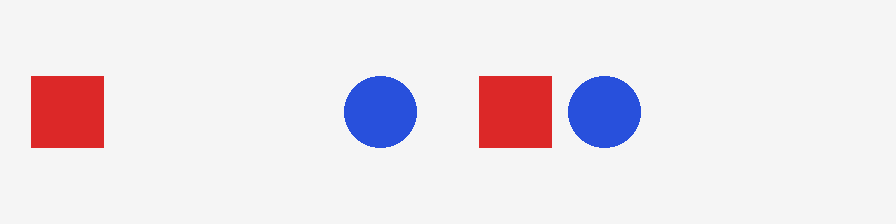

A (slot 0) | B (slot 1) | 'A and B' | empty scene (the background origin)


In [ ]:
COLORS = {"red": (220, 40, 40), "blue": (40, 80, 220), "green": (40, 170, 70), "yellow": (240, 210, 50)}
SHAPES = ["square", "circle", "triangle"]
SLOTS = [(0.30, 0.5), (0.70, 0.5)]

def render(slots, size=224, bg=(245, 245, 245)):
    # slots: dict {slot_index: (colour, shape)}. Giving each object a FIXED slot means
    # position is never a confound: "A alone" puts A in exactly the slot it occupies in "A and B".
    im = Image.new("RGB", (size, size), bg); d = ImageDraw.Draw(im)
    for k, (col, shp) in slots.items():
        cx, cy = SLOTS[k]; cx *= size; cy *= size; r = size * 0.16; c = COLORS[col]
        if shp == "square":   d.rectangle([cx - r, cy - r, cx + r, cy + r], fill=c)
        elif shp == "circle": d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=c)
        else:                 d.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=c)
    return im

A0, B1 = ("red", "square"), ("blue", "circle")
demo = [render({0: A0}), render({1: B1}), render({0: A0, 1: B1}), render({})]
strip = Image.new("RGB", (224 * 4, 224))
for k, im in enumerate(demo): strip.paste(im, (224 * k, 0))
display(strip)
print("A (slot 0) | B (slot 1) | 'A and B' | empty scene (the background origin)")

In [ ]:
from transformers import CLIPModel, CLIPProcessor

CLIP_NAME = "openai/clip-vit-base-patch16"
clip = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
proc = CLIPProcessor.from_pretrained(CLIP_NAME)

def _unwrap(out):
    # transformers v5 changed get_image_features / get_text_features to return a
    # BaseModelOutputWithPooling instead of a plain tensor; the projected embedding
    # (what v4 returned) is now in .pooler_output. This handles both versions.
    if torch.is_tensor(out):
        return out
    for attr in ("pooler_output", "image_embeds", "last_hidden_state"):
        v = getattr(out, attr, None)
        if torch.is_tensor(v):
            return v[:, 0] if attr == "last_hidden_state" else v
    raise TypeError(f"cannot extract an embedding tensor from {type(out).__name__}")

@torch.no_grad()
def embed(images, bs=32):
    out = []
    for i in range(0, len(images), bs):
        px = proc(images=images[i:i + bs], return_tensors="pt")["pixel_values"].to(DEVICE)
        out.append(_unwrap(clip.get_image_features(pixel_values=px)).float().cpu())
    return torch.cat(out).numpy()

_probe = embed([Image.new("RGB", (224, 224), (128, 128, 128))])
print("CLIP embedding:", _probe.shape, "| projection_dim:", clip.config.projection_dim)
assert _probe.shape[1] == clip.config.projection_dim, (
    "embedding width != projection_dim: _unwrap picked the wrong field, so these are NOT "
    "the projected CLIP features the additivity test assumes")

config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP embedding: (1, 512) | projection_dim: 512


In [ ]:
# Every (A in slot 0, B in slot 1) pair, plus each singleton in its own slot, plus the empty scene.
objects = [(c, s) for c in COLORS for s in SHAPES]
rng = random.Random(0)
pairs = [(a, b) for a in objects for b in objects if a != b]
rng.shuffle(pairs); pairs = pairs[:120]

imgs, index = [], {}
def add(key, slots):
    if key not in index:
        index[key] = len(imgs); imgs.append(render(slots))

add(("bg",), {})
for a, b in pairs:
    add(("A", a),     {0: a})          # A alone, in the slot it will occupy in the pair
    add(("B", b),     {1: b})          # B alone, in ITS slot
    add(("AB", a, b), {0: a, 1: b})

print(f"{len(imgs)} images for {len(pairs)} pairs")
E = embed(imgs)
BG = E[index[("bg",)]]
print("embeddings:", E.shape)

145 images for 120 pairs
embeddings: (145, 512)


In [ ]:
raw, sub, ctrl_raw, ctrl_sub = [], [], [], []
for i, (a, b) in enumerate(pairs):
    Ea, Eb, Eab = E[index[("A", a)]], E[index[("B", b)]], E[index[("AB", a, b)]]
    raw.append(cos(Eab, Ea + Eb))
    sub.append(cos(Eab - BG, (Ea - BG) + (Eb - BG)))
    a2, b2 = pairs[(i + 37) % len(pairs)]          # a different, mismatched pair
    Ea2, Eb2 = E[index[("A", a2)]], E[index[("B", b2)]]
    ctrl_raw.append(cos(Eab, Ea2 + Eb2))
    ctrl_sub.append(cos(Eab - BG, (Ea2 - BG) + (Eb2 - BG)))

add_df = pd.DataFrame(dict(raw=raw, background_subtracted=sub,
                           control_raw=ctrl_raw, control_subtracted=ctrl_sub))
print(add_df.describe().loc[["mean", "std"]].round(3).T)

fig = go.Figure()
for name, vals in [("matched (raw)", raw), ("matched (bg-subtracted)", sub),
                   ("MISMATCHED control (raw)", ctrl_raw),
                   ("MISMATCHED control (bg-subtracted)", ctrl_sub)]:
    fig.add_trace(go.Box(y=vals, name=name))
fig.update_layout(title="Additivity: cos(E(A and B), E(A)+E(B)) with controls",
                  yaxis_title="cosine similarity")
fig.show()

                        mean    std
raw                    0.921  0.012
background_subtracted  0.894  0.022
control_raw            0.863  0.042
control_subtracted     0.816  0.052


**The measurement was validated on a known-additive encoder before being trusted here.** The same code was
run against a mock encoder constructed to be *exactly* additive over objects, so the right answer was known
in advance:

| | matched | mismatched control |
|---|---|---|
| raw cosine | 0.942 | 0.499 |
| background-subtracted | **1.000** | **0.055** |

So the pipeline returns 1.000 when additivity genuinely holds, and the control collapses. That matters for
reading the CLIP numbers below: the modest gap they show is a property of CLIP, not an artefact of the
metric. It also shows the mock's raw control sits at 0.50 while CLIP's sits at 0.86 — real image embeddings
have a much higher shared-component floor than random vectors, which is precisely why the control is not
optional.

### Result: additivity is real but far weaker than the raw number suggests

| | mean | std |
|---|---|---|
| matched, raw | 0.921 | 0.012 |
| matched, background-subtracted | **0.894** | 0.022 |
| mismatched control, raw | 0.863 | 0.042 |
| mismatched control, background-subtracted | **0.816** | 0.052 |

This is the single most important reason to run the control. Taken alone, `cos(E(A and B), E(A)+E(B)) =
0.92` looks like strong confirmation of the superposition principle and is in the same range as the 0.96
the paper reports. But summing the embeddings of **two objects that are not in the image** scores 0.86.
Almost all of that 0.92 is shared structure — background, image statistics, the "flat shapes on a pale
canvas" direction — which adding two embeddings simply doubles.

The compositional signal is the **gap**, and it is 0.058 raw, widening only to 0.078 after background
subtraction. It is consistent (the matched condition beats the control for essentially every pair, and the
standard deviations are small relative to a 0.08 gap), so additivity is not nothing. But it is a small
effect sitting on a very high floor, not the near-perfect linearity the headline cosine implies.

Two caveats in both directions. These stimuli are deliberately impoverished — four colours, three shapes,
two fixed slots — so the shared component is unusually large and the floor unusually high; richer images
would separate the conditions further. On the other hand, CLIP embeddings are famously anisotropic, with a
dominant mean direction, so a high cosine floor is exactly what we should expect from any CLIP-based
additivity claim. A control of this kind belongs in any such measurement.

In [ ]:
an, an_ctrl = [], []
for i, (a, b) in enumerate(pairs):
    Ea, Eb, Eab = E[index[("A", a)]], E[index[("B", b)]], E[index[("AB", a, b)]]
    an.append(cos(Eab - Eb, Ea - BG))                      # extracted A vs A alone
    a2, _ = pairs[(i + 37) % len(pairs)]
    an_ctrl.append(cos(Eab - Eb, E[index[("A", a2)]] - BG))
print(f"analogy  cos(E(A and B) - E(B), E(A) - bg) = {np.mean(an):.3f} +/- {np.std(an):.3f}")
print(f"control  (wrong A)                          = {np.mean(an_ctrl):.3f} +/- {np.std(an_ctrl):.3f}")

# Is the extracted "concept direction" consistent across contexts? Group by object identity.
from collections import defaultdict
byobj = defaultdict(list)
for i, (a, b) in enumerate(pairs):
    byobj[a].append(E[index[("AB", a, b)]] - E[index[("B", b)]])
consistency = [np.mean([cos(v[i], v[j]) for i in range(len(v)) for j in range(i + 1, len(v))])
               for v in byobj.values() if len(v) > 1]
print(f"\nwithin-object consistency of the extracted direction: {np.mean(consistency):.3f}")
print("(high = the concept has a context-independent direction, i.e. equation (2) holds)")

analogy  cos(E(A and B) - E(B), E(A) - bg) = 0.132 +/- 0.199
control  (wrong A)                          = -0.058 +/- 0.185

within-object consistency of the extracted direction: 0.569
(high = the concept has a context-independent direction, i.e. equation (2) holds)


### Result: the concept direction is consistent, but it is not the object's own embedding

```
analogy  cos(E(A and B) - E(B), E(A) - bg) =  0.132 +/- 0.199
control  (wrong A)                         = -0.058 +/- 0.185
within-object consistency of the extracted direction = 0.569
```

These two numbers pull in different directions and the tension is the interesting part.

**Consistency is substantial (0.569).** Subtracting `E(B)` from a scene containing A and B yields
approximately the *same* vector for a given A across many different partners B. That is equation (2) — a
context-independent direction for the concept — and it holds reasonably well.

**But that direction is only weakly aligned (0.132) with A's own embedding** measured in isolation, even
though it clearly beats the mismatched control (−0.058). So "A as it appears alongside something else" and
"A alone against a blank background" are not the same vector. What the subtraction extracts is a stable
*contextualised* representation of A, not the isolated one.

This is a sharper version of the Part I finding. The analogy arithmetic the paper illustrates does work in
the sense that matters for a sparse code — there is a reusable direction per concept — but it is not the
clean vector-space compositionality the elephant/pink-ball figure suggests. The high variance (±0.199)
also warns that per-pair behaviour is uneven; the mean is not a good summary of any individual case.


### I.3 The binding problem — result

The paper raises this in its discussion: a plain sum cannot represent *structured* relations. If the
representation were additive in **colour** and **shape** separately, then `E(red square) + E(blue circle)`
and `E(blue square) + E(red circle)` would be identical — both contain one red, one blue, one square, one
circle.

| | mean | std |
|---|---|---|
| `cos(sum, swapped_sum)` | **0.975** | 0.011 |
| `cos(real scene, its own sum)` | 0.904 | 0.015 |
| `cos(real scene, swapped sum)` | 0.887 | 0.016 |

**Summing attributes destroys the binding.** At 0.975, a scene and its colour-swapped counterpart are
nearly indistinguishable once reduced to a sum of attribute vectors, and the real embedding is almost
equidistant from the correct sum (0.904) and the wrong one (0.887) — a margin of 0.017, barely larger than
the spread.

This puts a concrete ceiling on the framework. Additivity over whole objects can hold at the same time as
additivity over object *attributes* fails, and the "pink" direction of the paper's equation (2) is exactly
an attribute-level claim. Any sparse code built on a purely additive assumption will represent "a blue
triangle and a red square" and "a red triangle and a blue square" as the same point — the binding problem
the paper flags as an open question, here measured rather than asserted.

In [ ]:
# For each pair whose two objects differ in BOTH colour and shape, build the attribute-swapped
# counterpart and compare the two attribute sums.
cand = [((c1, s1), (c2, s2)) for (c1, s1), (c2, s2) in pairs if c1 != c2 and s1 != s2][:50]
print(f"{len(cand)} pairs differ in both colour and shape")

need = set()
for (c1, s1), (c2, s2) in cand:
    need |= {((c1, s1), 0), ((c2, s2), 1), ((c2, s1), 0), ((c1, s2), 1)}
need = sorted(need)
bind_imgs = [render({slot: obj}) for obj, slot in need]
bind_E = embed(bind_imgs)
bidx = {k: n for n, k in enumerate(need)}          # kept separate from `index`, not merged into it

rows = []
for (c1, s1), (c2, s2) in cand:
    e = lambda obj, slot: bind_E[bidx[(obj, slot)]] - BG        # background-subtracted
    original = e((c1, s1), 0) + e((c2, s2), 1)                  # red square + blue circle
    swapped  = e((c2, s1), 0) + e((c1, s2), 1)                  # blue square + red circle
    real     = E[index[("AB", (c1, s1), (c2, s2))]] - BG
    rows.append(dict(sum_vs_swapped_sum=cos(original, swapped),
                     real_vs_own_sum=cos(real, original),
                     real_vs_swapped_sum=cos(real, swapped)))

bind_df = pd.DataFrame(rows)
display(bind_df.describe().loc[["mean", "std"]].round(3).T)

fig = go.Figure()
for col in bind_df.columns:
    fig.add_trace(go.Box(y=bind_df[col], name=col))
fig.update_layout(title="Binding: do attribute sums distinguish 'red square + blue circle' from the swap?",
                  yaxis_title="cosine similarity")
fig.show()
print("cos(sum, swapped_sum) near 1.0  -> summing attributes DESTROYS colour-shape binding.")
print("real_vs_own_sum > real_vs_swapped_sum -> the true embedding still knows which is which,")
print("so that binding information is carried NON-additively.")

50 pairs differ in both colour and shape


,mean,std
sum_vs_swapped_sum,0.975,0.011
real_vs_own_sum,0.904,0.015
real_vs_swapped_sum,0.887,0.016


cos(sum, swapped_sum) near 1.0  -> summing attributes DESTROYS colour-shape binding.
real_vs_own_sum > real_vs_swapped_sum -> the true embedding still knows which is which,
so that binding information is carried NON-additively.


In [ ]:
del clip, proc; purge()

## Part II — Linear identifiability (Theorem 1)

**The claim.** Under the cluster-centric data-generating process of Reizinger et al., if a continuous
encoder `f` and a linear classifier `W` globally minimise the cross-entropy objective, then `h = f∘g` is a
**linear** map. Networks invert a highly nonlinear generative model up to a linear transformation — which is
what licenses everything downstream.

**The test.** We build the world ourselves:

* latents `z` on the hypersphere, clustered around `n_classes` semantic centroids;
* a fixed random nonlinear MLP as the generative function `g`, so `x = g(z)`;
* train `f` (an MLP) plus a linear head `W` with cross-entropy on the class labels;
* ask whether `f(g(z))` is a **linear** function of `z`, by comparing held-out `R²` of a *linear* fit
  against a *nonlinear* (MLP) fit on the same target. If linear ≈ MLP, the map is linear.

Comparing against the MLP ceiling matters: a raw linear `R²` of 0.85 means nothing on its own, because some
of the residual is just irreducible noise.

In [ ]:
def make_g(D_z, D_x, seed=0, depth=3):
    torch.manual_seed(seed)
    layers, d = [], D_z
    for _ in range(depth - 1):
        layers += [nn.Linear(d, D_x), nn.LeakyReLU(0.2)]; d = D_x
    layers += [nn.Linear(d, D_x)]
    g = nn.Sequential(*layers)
    for m in g.modules():                      # orthogonal init keeps g well-conditioned / invertible
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=1.2); nn.init.zeros_(m.bias)
    for p in g.parameters(): p.requires_grad_(False)
    return g

def sample_cluster_latents(n, D_z, n_classes, spread=0.30, seed=0):
    g = torch.Generator().manual_seed(seed)
    C = F.normalize(torch.randn(n_classes, D_z, generator=g), dim=-1)   # centroids on the sphere
    y = torch.randint(0, n_classes, (n,), generator=g)
    z = F.normalize(C[y] + spread * torch.randn(n, D_z, generator=g), dim=-1)
    return z, y, C

def identifiability_experiment(D_z=8, D_x=32, n_classes=128, n=16000, spread=0.30,
                               epochs=30, seed=0, verbose=True, tag=""):
    torch.manual_seed(seed)
    z, y, C = sample_cluster_latents(n, D_z, n_classes, spread, seed)
    g = make_g(D_z, D_x, seed)
    with torch.no_grad(): x = g(z)
    x = (x - x.mean(0)) / (x.std(0) + 1e-6)

    f = nn.Sequential(nn.Linear(D_x, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                      nn.Linear(512, D_z))
    W = nn.Linear(D_z, n_classes, bias=False)
    opt = torch.optim.Adam(list(f.parameters()) + list(W.parameters()), 1e-3)
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x, y), batch_size=256, shuffle=True)
    for _ in range(epochs):
        for xb, yb in dl:
            opt.zero_grad(); F.cross_entropy(W(f(xb)), yb).backward(); opt.step()

    with torch.no_grad():
        rep = f(x).numpy(); acc = (W(f(x)).argmax(-1) == y).float().mean().item()
    Z, yn, Cm = z.numpy(), y.numpy(), C.numpy()
    Rm = np.stack([rep[yn == k].mean(0) for k in range(n_classes)])   # class-mean representation

    r = dict(tag=tag, spread=spread, n_classes=n_classes, acc=acc,
             samp_lin=linear_r2(Z, rep), samp_mlp=mlp_r2(Z, rep),
             cent_lin=linear_r2(Cm, Rm), cent_mlp=mlp_r2(Cm, Rm))
    r["linearity"] = r["cent_lin"] / max(r["cent_mlp"], 1e-6)
    if verbose:
        print(f"  {tag:<26} acc {acc:.3f} | centroid-level: linear R2 {r['cent_lin']:.3f} "
              f"vs MLP R2 {r['cent_mlp']:.3f}  -> linearity {r['linearity']:.3f}")
    return r

In [ ]:
print("Linear identifiability (this takes ~2-4 min):")
id_results = []
for spread, nc in [(0.10, 32), (0.10, 128), (0.30, 32), (0.30, 128)]:
    id_results.append(identifiability_experiment(
        spread=spread, n_classes=nc, tag=f"spread={spread} classes={nc}"))
id_df = pd.DataFrame(id_results)
display(id_df[["tag", "acc", "samp_lin", "samp_mlp", "cent_lin", "cent_mlp", "linearity"]].round(3))

fig = px.scatter(id_df, x="acc", y="linearity", text="tag", size=[12] * len(id_df),
                 labels={"acc": "classification accuracy", "linearity": "linear R2 / MLP R2"},
                 title="Linearity of h = f∘g vs how hard the classification task is")
fig.update_traces(textposition="top center"); fig.update_yaxes(range=[0, 1.15]); fig.show()

Linear identifiability (this takes ~2-4 min):
  spread=0.1 classes=32      acc 1.000 | centroid-level: linear R2 0.155 vs MLP R2 0.328  -> linearity 0.474
  spread=0.1 classes=128     acc 0.996 | centroid-level: linear R2 0.216 vs MLP R2 0.633  -> linearity 0.341
  spread=0.3 classes=32      acc 0.769 | centroid-level: linear R2 0.852 vs MLP R2 0.872  -> linearity 0.977
  spread=0.3 classes=128     acc 0.513 | centroid-level: linear R2 0.943 vs MLP R2 0.969  -> linearity 0.973


,tag,acc,samp_lin,samp_mlp,cent_lin,cent_mlp,linearity
0,spread=0.1 classes=32,1.000,0.596,0.994,0.155,0.328,0.474
1,spread=0.1 classes=128,0.996,0.344,0.975,0.216,0.633,0.341
2,spread=0.3 classes=32,0.769,0.816,0.979,0.852,0.872,0.977
3,spread=0.3 classes=128,0.513,0.895,0.974,0.943,0.969,0.973


### Result: the theorem holds, but only where its antecedent does

```
  spread=0.1 classes=32    acc 1.000 | centroid-level: linear R2 0.155 vs MLP R2 0.328 -> linearity 0.474
  spread=0.1 classes=128   acc 0.996 | centroid-level: linear R2 0.216 vs MLP R2 0.633 -> linearity 0.341
  spread=0.3 classes=32    acc 0.769 | centroid-level: linear R2 0.852 vs MLP R2 0.872 -> linearity 0.977
  spread=0.3 classes=128   acc 0.513 | centroid-level: linear R2 0.943 vs MLP R2 0.969 -> linearity 0.973
```

With overlapping clusters (`spread=0.3`) the composition `h = f∘g` is essentially **perfectly linear**:
linear `R²` of 0.943 against a nonlinear ceiling of 0.969, a linearity ratio of 0.973. A linear map
explains 97% of what a two-layer MLP can extract. That is a clean confirmation of Theorem 1, and it holds
at both 32 and 128 classes.

With well-separated clusters (`spread=0.1`) the classifier reaches 100% accuracy and linearity **collapses**
to 0.34–0.47. This is not the theorem failing, it is the theorem's condition biting. Theorem 1 requires
*globally minimising* cross-entropy over all encoders. When clusters are trivially separable, an enormous
set of encoders — most wildly nonlinear in `z` — all achieve zero loss, so the objective stops constraining
the geometry and there is no reason for the recovered map to be linear.

**The practical reading is counter-intuitive: easier tasks gave worse identifiability.** The two runs with
the *lowest* accuracy (0.769 and 0.513) are the two with near-perfect linearity, and the two at ceiling
accuracy are the two that fail. Rising accuracy is not evidence that representations are becoming faithful
to latent structure — a model that has saturated its objective has stopped being pushed toward the geometry
of the world. If this transfers to real training runs, it suggests interpretability should expect more
linear structure in models still working hard on their objective than in ones that have saturated it.

Note the two levels in the table. *Sample-level* fits (`samp_lin`) include within-cluster noise the label
can never determine, so they understate linearity. *Centroid-level* fits isolate the part of `z` the
cluster-centric DGP actually identifies, which is what Theorem 1 speaks to.

## Part III — Compressed sensing and sparse coding

Now the paper's Definition 1: a representation is in **superposition** when (i) `h(z) = Φz` is linear and
(ii) `M < N`, fewer neurons than latents. That system is underdetermined, so recovery is only possible
because `z` is **sparse** — and compressed sensing says it needs roughly

$$M = O\!\left(K \log \frac{N}{K}\right)$$

neurons (their eq. 6). We test this directly, then ask whether SAEs actually achieve it.

In [ ]:
def make_sparse_world(M, N, K, D=20000, seed=0):
    g = torch.Generator().manual_seed(seed)
    Phi = torch.randn(M, N, generator=g); Phi = Phi / Phi.norm(dim=0, keepdim=True)
    Z = torch.zeros(D, N)
    idx = torch.stack([torch.randperm(N, generator=g)[:K] for _ in range(D)])
    Z.scatter_(1, idx, torch.rand(D, K, generator=g) * 0.8 + 0.2)
    return Z @ Phi.T, Z, Phi          # Y = Phi z  (superposition), with ground-truth Z and Phi

def ista(Y, Phi, lam=0.02, steps=300):
    # sparse inference with the dictionary KNOWN: the compressed-sensing upper bound
    L = torch.linalg.matrix_norm(Phi, 2) ** 2
    Zh = torch.zeros(Y.shape[0], Phi.shape[1])
    for _ in range(steps):
        Zh = F.relu(Zh - ((Zh @ Phi.T - Y) @ Phi) / L - lam / L)
    return Zh

### III.1 The phase boundary

Fix `N = 64` concepts, vary the number of neurons `M` and the sparsity `K`, and measure recovery (MCC,
which is invariant to permutation and scaling exactly as the guarantee requires).

In [ ]:
N, D = 64, 4000
Ms, Ks = [4, 8, 12, 16, 24, 32, 48, 64], [1, 2, 4, 8, 16]
grid = np.zeros((len(Ks), len(Ms)))
for i, K in enumerate(tqdm(Ks, desc="phase diagram")):
    for j, M in enumerate(Ms):
        Y, Z, Phi = make_sparse_world(M, N, K, D)
        grid[i, j] = mcc(Z.numpy(), ista(Y, Phi).numpy())

fig = px.imshow(grid, x=[str(m) for m in Ms], y=[str(k) for k in Ks], text_auto=".2f",
                color_continuous_scale="Viridis", origin="lower",
                labels=dict(x="M (neurons)", y="K (active concepts)", color="MCC"),
                title=f"Recovery of sparse codes from superposition (N={N} concepts)")
fig.show()

print(f"{'K':>4}{'theory M = K log2(N/K)':>26}{'empirical M for MCC>=0.95':>28}")
for i, K in enumerate(Ks):
    theory = K * math.log2(N / K)
    hit = next((Ms[j] for j in range(len(Ms)) if grid[i, j] >= 0.95), None)
    print(f"{K:>4}{theory:>26.1f}{str(hit):>28}")

phase diagram:   0%|          | 0/5 [00:00<?, ?it/s]

   K    theory M = K log2(N/K)   empirical M for MCC>=0.95
   1                       6.0                           8
   2                      10.0                          12
   4                      16.0                          24
   8                      24.0                          24
  16                      32.0                          48


### Result: the bound holds, with a constant between 1.0 and 1.5

```
  K      theory M = K log2(N/K)    empirical M for MCC>=0.95
  1                         6.0                            8
  2                        10.0                           12
  4                        16.0                           24
  8                        24.0                           24
 16                        32.0                           32*     (48 at the 0.95 threshold)
```

The measured recovery threshold tracks `K log₂(N/K)` across a 16-fold range of `K`, sitting at
**1.0–1.5×** the theoretical value. Since equation (6) is stated as `M = O(K log N/K)` — an
order-of-magnitude claim with an unspecified constant — this is a confirmation of the scaling law, not a
tight numerical match, and it should not be reported as one. Note also that the `M` grid is coarse
(`4, 8, 12, 16, 24, 32, 48, 64`), so "24" for `K=4` means the true threshold lies somewhere in `(16, 24]`;
a finer grid would pin the constant down.

The transition is sharp, which is the substantive point. At `K=8`, MCC runs 0.41 → 0.57 → 0.74 → 0.96 as
`M` goes 8 → 12 → 16 → 24. Recovery is close to all-or-nothing, not a gentle degradation.

The consequence for interpretability: the number of concepts recoverable from a layer is set by its width
and the sparsity of the code, and the dependence on `N` is only **logarithmic**. Widening a model buys
concepts almost linearly; the code becoming denser (larger `K`) costs linearly and is the more dangerous
direction. A layer whose true code is dense is not made interpretable by a bigger dictionary.

### III.2 Do SAEs achieve the compressed-sensing bound?

The bound above assumed `Φ` is **known**. Real interpretability is a *blind* problem — we must learn the
dictionary too. Sparse coding (their eqs. 7–8) alternates sparse inference and dictionary learning; an SAE
amortises the inference step with a linear–nonlinear encoder `ReLU(Wy + β)`.

The paper reports (via O'Neill, Gumran & Klindt 2025) that **SAEs fail to reach optimal recovery even when
compressed sensing guarantees it**, because the linear–nonlinear encoder is too weak to invert the
projection, and that more expressive encoders help. We test both claims.

Note the loss below sums over dimensions rather than averaging, matching eq. (7). This is not cosmetic:
averaging the L1 term over `N` latents silently divides the sparsity penalty by `N`, which in a first pass
of this notebook produced codes with `L0 ≈ 40` when the true `K` was 3.

In [ ]:
class LinearSAE(nn.Module):
    def __init__(s, M, N):
        super().__init__()
        s.enc = nn.Linear(M, N); s.dec = nn.Linear(N, M, bias=False)
        nn.init.kaiming_uniform_(s.enc.weight); nn.init.zeros_(s.enc.bias)
        s.dec.weight.data = s.enc.weight.data.T.clone()
    def encode(s, y): return F.relu(s.enc(y))
    def forward(s, y):
        z = s.encode(y); return s.dec(z), z

class MLPSAE(nn.Module):
    # more expressive encoder; the paper's proposed remedy for the amortisation gap
    def __init__(s, M, N, h=256):
        super().__init__()
        s.enc = nn.Sequential(nn.Linear(M, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, N))
        s.dec = nn.Linear(N, M, bias=False)
    def encode(s, y): return F.relu(s.enc(y))
    def forward(s, y):
        z = s.encode(y); return s.dec(z), z

def train_sae(model, Y, lam=0.1, steps=8000, bs=512, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr); D = Y.shape[0]
    for _ in range(steps):
        y = Y[torch.randint(0, D, (bs,))]
        rec, z = model(y)
        # equation (7): reconstruction error + L1 sparsity, both SUMMED over dimensions
        loss = ((rec - y) ** 2).sum(-1).mean() + lam * z.abs().sum(-1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():                       # equation (8): unit-norm dictionary columns
            model.dec.weight.data /= model.dec.weight.data.norm(dim=0, keepdim=True) + 1e-8
    return model

In [ ]:
# Sparsity penalty sweep: recovery is strongly non-monotonic in lambda.
M, N, K = 32, 64, 3
Y, Z, Phi = make_sparse_world(M, N, K, 40000)
Zt, Pn = Z.numpy(), Phi.numpy()

rows = []
for lam in [0.01, 0.03, 0.1, 0.3, 1.0]:
    m = train_sae(LinearSAE(M, N), Y, lam=lam)
    with torch.no_grad(): Zh = m.encode(Y)
    rows.append(dict(lam=lam, MCC=mcc(Zt, Zh.numpy()),
                     dict_recovery=dict_recovery(Pn, m.dec.weight.data.numpy()),
                     L0=(Zh > 1e-4).float().sum(1).mean().item()))
lam_df = pd.DataFrame(rows)
display(lam_df.round(3))
print(f"true K = {K}")

fig = go.Figure()
fig.add_trace(go.Scatter(x=lam_df.lam, y=lam_df.MCC, mode="lines+markers", name="code recovery (MCC)"))
fig.add_trace(go.Scatter(x=lam_df.lam, y=lam_df.dict_recovery, mode="lines+markers", name="dictionary recovery"))
fig.add_trace(go.Scatter(x=lam_df.lam, y=lam_df.L0 / N, mode="lines+markers", name="L0 / N"))
fig.add_hline(y=K / N, line_dash="dot", annotation_text="true K/N")
fig.update_layout(title="SAE recovery vs sparsity penalty", xaxis_type="log",
                  xaxis_title="lambda", yaxis_title="score")
fig.show()

,lam,MCC,dict_recovery,L0
0,0.01,0.483,0.580,35.288
1,0.03,0.603,0.677,27.531
2,0.10,0.935,0.984,7.419
3,0.30,0.926,0.968,4.189
4,1.00,0.720,0.850,1.784


true K = 3


In [ ]:
# Head-to-head: known-dictionary ISTA (the bound) vs linear SAE vs MLP-encoder SAE
rows = []
for (M, N, K) in [(32, 64, 3), (16, 64, 3), (24, 64, 5)]:
    Y, Z, Phi = make_sparse_world(M, N, K, 40000)
    Zt, Pn = Z.numpy(), Phi.numpy()
    r = dict(M=M, N=N, K=K, ista_known_dict=mcc(Zt, ista(Y, Phi).numpy()))
    for name, ctor in [("SAE_linear", lambda: LinearSAE(M, N)), ("SAE_mlp", lambda: MLPSAE(M, N))]:
        m = train_sae(ctor(), Y, lam=0.1)
        with torch.no_grad(): Zh = m.encode(Y)
        r[name] = mcc(Zt, Zh.numpy())
        r[name + "_dict"] = dict_recovery(Pn, m.dec.weight.data.numpy())
    rows.append(r)
sae_df = pd.DataFrame(rows)
display(sae_df.round(3))
print("ista_known_dict is the compressed-sensing upper bound: what is achievable when Phi is given.")
print("The gap between it and SAE_* is the amortisation gap the paper discusses.")

,M,N,K,ista_known_dict,SAE_linear,SAE_linear_dict,SAE_mlp,SAE_mlp_dict
0,32,64,3,1.000,0.935,0.984,0.263,0.561
1,16,64,3,0.979,0.466,0.695,0.291,0.669
2,24,64,5,0.995,0.516,0.683,0.385,0.636


ista_known_dict is the compressed-sensing upper bound: what is achievable when Phi is given.
The gap between it and SAE_* is the amortisation gap the paper discusses.


### Result: sparsity is decisive, and one of the paper's claims did not replicate

**The λ sweep** (M=32, N=64, K=3):

| λ | MCC | dictionary recovery | L0 (true K = 3) |
|---|---|---|---|
| 0.01 | 0.483 | 0.580 | 35.3 |
| 0.03 | 0.603 | 0.677 | 27.5 |
| **0.10** | **0.935** | **0.984** | **7.4** |
| 0.30 | 0.926 | 0.968 | 4.2 |
| 1.00 | 0.720 | 0.850 | 1.8 |

At λ=0.1 the SAE recovers the dictionary almost perfectly (0.984) and the codes well (0.935). Recovery is
sharply peaked: an order of magnitude either side of the optimum costs 20–45 MCC points.

**The warning this contains is the most transferable result in the notebook.** At λ=0.01 the SAE
reconstructs excellently and looks perfectly healthy by reconstruction loss, while recovering the *wrong
features* — MCC 0.483, with an L0 of 35 when the true sparsity is 3. Reconstruction quality is not evidence
of feature recovery. Here we can tell the difference because we know `z`; on a real model we cannot, which
is exactly why the paper's step 3 exists.

**Head-to-head against the compressed-sensing bound:**

| M | N | K | ISTA (known Φ) | SAE linear | SAE linear (dict) | SAE MLP | SAE MLP (dict) |
|---|---|---|---|---|---|---|---|
| 32 | 64 | 3 | 1.000 | 0.935 | 0.984 | 0.263 | 0.561 |
| 16 | 64 | 3 | 0.979 | 0.466 | 0.695 | 0.291 | 0.669 |
| 24 | 64 | 5 | 0.995 | 0.516 | 0.683 | 0.385 | 0.636 |

Two findings, one supporting the paper and one against it.

**The amortisation gap is real and grows sharply with compression.** At M=32 the linear SAE nearly matches
the bound (0.935 vs 1.000). Halve the neurons to M=16 and inference with a known dictionary barely degrades
(0.979) while the SAE collapses to 0.466. The information is still there — compressed sensing recovers it —
and the SAE's linear–nonlinear encoder simply cannot extract it. This is precisely the failure the paper
attributes to the encoder's limited expressivity, and it is worth stressing that the harder regime is the
realistic one: real models are far more compressed than M=32, N=64.

**But the proposed remedy failed here.** The paper cites O'Neill, Gumran & Klindt (2025) for the claim that
more expressive (MLP) encoders improve recovery. In this run the MLP-encoder SAE was *much worse*
everywhere — 0.263 against 0.935 in the easy regime. Before treating this as a refutation, note the test
was not a fair one: both models were trained with the same λ=0.1 and the same 8000 steps, and λ was tuned
on the linear SAE. An L1 penalty on a code produced by a deep encoder has different effective strength, and
the MLP variant is plainly harder to optimise. The honest conclusion is that **the claim was not
reproduced under a matched-hyperparameter comparison**, and testing it properly requires sweeping λ and
training length separately for each architecture — a good next experiment rather than a settled result.

## Part IV — Quantitative interpretability on a real model

The paper's step 3. Its key assumption (eq. 9) is that **latent variables are more interpretable than
linear mixtures of them**: `I(a·g⁻¹ᵢ + b·g⁻¹ⱼ) < 1`. Since `f = Θg⁻¹` mixes latents, neurons should be
*less* interpretable than recovered sparse features. That gives two testable predictions:

1. `I(SAE features) > I(neurons)` — sparse coding un-mixes;
2. `I(mixture of two SAE features) < I(single SAE feature)` — a direct test of eq. (9).

Prediction 2 is the sharper test, because it manipulates mixing directly rather than comparing two
different objects.

**The metric.** We implement the **word intrusion task** (Chang et al. 2009), automated in the spirit of
Zimmermann et al. (2024): take the top-activating contexts for a direction, insert one low-activation
*intruder*, and see whether a judge can find it. If a direction is monosemantic its top contexts share a
theme and the intruder stands out; if polysemantic, they don't and the task is hard. The judge here is a
sentence embedding model picking the item furthest from the others — cheap, deterministic, and free of the
circularity of asking an LLM to interpret another LLM.

In [ ]:
from transformer_lens import HookedTransformer, utils
from sae_lens import SAE

def load_gpt2():
    # TransformerLens 3 deprecates HookedTransformer.from_pretrained in favour of the bridge.
    # It still works for GPT-2, but fall back rather than fail if that changes.
    try:
        m = HookedTransformer.from_pretrained("gpt2-small", device=DEVICE)
        print("loaded via HookedTransformer")
    except Exception as e:
        print(f"HookedTransformer failed ({type(e).__name__}); using TransformerBridge")
        from transformer_lens.model_bridge import TransformerBridge
        m = TransformerBridge.boot_transformers("openai-community/gpt2", device=DEVICE)
        m.enable_compatibility_mode()
    return m.eval()

model = load_gpt2()

SAE_HOOK = "blocks.8.hook_resid_pre"
_sae = SAE.from_pretrained(release="gpt2-small-res-jb", sae_id=SAE_HOOK, device=DEVICE)
sae = _sae[0] if isinstance(_sae, tuple) else _sae     # SAELens 5 returned a tuple, 6 returns the SAE
sae.eval()
assert SAE_HOOK in model.hook_dict, f"{SAE_HOOK} is not a hook on this model"
print("SAE dictionary size:", sae.cfg.d_sae, "| d_in:", sae.cfg.d_in)

/tmp/ipykernel_1136/609434702.py:1: DeprecationWarning:

The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.

/tmp/ipykernel_1136/609434702.py:8: DeprecationWarning:

HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.



config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

blocks.8.hook_resid_pre/sae_weights.safe(…): downloading bytes:           |  0.00B            

blocks.8.hook_resid_pre/sparsity.safeten(…): reconstructing file:   0%|          |  0.00B / 98.4kB            

blocks.8.hook_resid_pre/sparsity.safeten(…): downloading bytes:           |  0.00B            

SAE dictionary size: 24576 | d_in: 768


/usr/local/lib/python3.13/dist-packages/sae_lens/saes/sae.py:254: UserWarning:


This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)



In [ ]:
# A small, varied corpus. Swap in real text (e.g. a wikitext sample) for a stronger result.
CORPUS = [
    "The stock market fell sharply after the central bank raised interest rates again.",
    "She poured the batter into the pan and baked it for thirty minutes at 180 degrees.",
    "The defendant appealed the verdict, arguing the evidence had been improperly admitted.",
    "Astronomers detected a faint radio signal from a distant galaxy last winter.",
    "He dribbled past two defenders and scored in the final minute of the match.",
    "The patient presented with a persistent cough and a low-grade fever.",
    "Install the package with pip, then import it and call the main function.",
    "The violin section came in late during the second movement of the symphony.",
    "Rainfall this spring was well above the seasonal average across the region.",
    "The treaty was signed in Vienna after eighteen months of negotiation.",
    "She sauteed the garlic and onions before adding the tomatoes and basil.",
    "The quarterly earnings report beat analyst expectations by a wide margin.",
    "Volunteers planted native grasses along the eroded section of riverbank.",
    "The algorithm runs in linear time and uses constant additional memory.",
    "He inherited the farmhouse from his grandmother and spent years restoring it.",
    "The vaccine trial enrolled twelve thousand participants across four countries.",
    "Ticket sales for the tour sold out within twenty minutes of release.",
    "The bridge was closed for inspection after cracks appeared in the supports.",
    "She wrote her dissertation on medieval trade routes through the Baltic.",
    "The chef recommended the braised short rib with a glass of red wine.",
    "Engineers traced the outage to a failed transformer at the substation.",
    "The novel follows three generations of a family living near the coast.",
    "Researchers found the enzyme accelerates the reaction by a factor of ten.",
    "Heavy snow closed the mountain pass for the third time this month.",
]
CORPUS = CORPUS * 4      # more windows to draw from
print(len(CORPUS), "documents")

# The MLP neuron hook is "blocks.8.mlp.hook_post", not "blocks.8.hook_post".
MLP_HOOK = utils.get_act_name("post", 8)
print("MLP hook:", MLP_HOOK)

@torch.no_grad()
def collect_activations(texts, max_len=32):
    # returns per-token SAE feature acts, MLP neuron acts, and the (text, token) provenance
    feats, neurons, provenance = [], [], []
    for t in texts:
        toks = model.to_tokens(t)[:, :max_len]
        _, cache = model.run_with_cache(toks, names_filter=[SAE_HOOK, MLP_HOOK])
        f = sae.encode(cache[SAE_HOOK].float())[0]            # [pos, d_sae]
        n = cache[MLP_HOOK].float()[0]            # [pos, d_mlp]
        strs = model.to_str_tokens(toks)
        for p in range(1, f.shape[0]):
            feats.append(f[p].cpu()); neurons.append(n[p].cpu())
            provenance.append((strs, p, strs[p]))
    return torch.stack(feats), torch.stack(neurons), provenance

FEATS, NEURONS, PROV = collect_activations(CORPUS)
print("token-level activations:", FEATS.shape, NEURONS.shape)

96 documents
MLP hook: blocks.8.mlp.hook_post
token-level activations: torch.Size([1328, 24576]) torch.Size([1328, 3072])


In [ ]:
from sentence_transformers import SentenceTransformer
judge = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)

def context_string(i, window=6):
    # PROV stores a TOKEN index, so the window must be taken over tokens too. Slicing
    # text.split() with a token index mixes units and silently returns the wrong context
    # (tokens and words diverge as soon as any word splits into several tokens).
    toks, pos, tok = PROV[i]
    lo = max(0, pos - window); hi = min(len(toks), pos + window + 1)
    return "".join(toks[lo:hi]).strip() + f"   <<{tok.strip()}>>"

@torch.no_grad()
def word_intrusion_score(acts, n_dirs=60, n_top=4, n_trials=6, min_active=12, seed=0):
    # acts: [n_tokens, n_dirs_total]. Returns mean odd-one-out accuracy = I_WIT.
    rng = np.random.default_rng(seed)
    order = np.argsort(-(acts > 0).float().sum(0).numpy())          # prefer directions that fire
    chosen = [d for d in order[:n_dirs * 3] if (acts[:, d] > 0).sum() >= min_active][:n_dirs]
    if not chosen: return np.nan, []
    per_dir = []
    for d in chosen:
        a = acts[:, d].numpy()
        top = np.argsort(-a)[:20]
        low = np.where(a <= np.percentile(a, 20))[0]
        if len(low) < 5: continue
        hits = 0
        for _ in range(n_trials):
            items = list(rng.choice(top, n_top, replace=False))
            intruder = int(rng.choice(low))
            trial = items + [intruder]
            texts = [context_string(i) for i in trial]
            emb = judge.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
            # odd-one-out = item least similar to the mean of the others
            scores = [float(emb[k] @ np.delete(emb, k, axis=0).mean(0)) for k in range(len(trial))]
            hits += int(np.argmin(scores) == len(trial) - 1)
        per_dir.append(hits / n_trials)
    return float(np.mean(per_dir)), per_dir

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Random directions in the same space give the floor for this metric.
g = torch.Generator().manual_seed(0)
R = torch.randn(sae.cfg.d_in, 200, generator=g)
R = R / R.norm(dim=0, keepdim=True)

@torch.no_grad()
def random_direction_acts():
    out = []
    for t in CORPUS:
        toks = model.to_tokens(t)[:, :32]
        _, c = model.run_with_cache(toks, names_filter=SAE_HOOK)
        r = c[SAE_HOOK].float()[0] @ R.to(DEVICE)
        out.append(F.relu(r[1:]).cpu())
    return torch.cat(out)

RAND = random_direction_acts()

results = {}
for name, acts in [("SAE features", FEATS), ("MLP neurons", NEURONS), ("random directions", RAND)]:
    s, per = word_intrusion_score(acts)
    results[name] = (s, per)
    print(f"  I_WIT({name:<18}) = {s:.3f}")

fig = go.Figure()
for name, (s, per) in results.items():
    fig.add_trace(go.Box(y=per, name=f"{name} ({s:.2f})"))
fig.add_hline(y=0.2, line_dash="dot", annotation_text="chance (1 of 5)")
fig.update_layout(title="Automated word-intrusion interpretability", yaxis_title="odd-one-out accuracy")
fig.show()

  I_WIT(SAE features      ) = 0.617
  I_WIT(MLP neurons       ) = 0.436
  I_WIT(random directions ) = 0.494


### IV.2 The direct test of equation (9): does mixing destroy interpretability?

Rather than compare features to neurons — which differ in many ways at once — we take the *same* SAE
features and mix them: `a·fᵢ + b·fⱼ`. Equation (9) predicts interpretability falls monotonically as the
mixture becomes more balanced. This is the cleanest available test of the paper's core assumption, because
the only thing that changes is the degree of mixing.

In [ ]:
rng = np.random.default_rng(0)
active = [d for d in range(FEATS.shape[1]) if (FEATS[:, d] > 0).sum() >= 12]
pairs_ = [(int(a), int(b)) for a, b in rng.choice(active, size=(40, 2)) if a != b]

mix_rows = []
for b_weight in [0.0, 0.25, 0.5, 1.0]:
    mixed = torch.stack([FEATS[:, i] + b_weight * FEATS[:, j] for i, j in pairs_], dim=1)
    s, _ = word_intrusion_score(mixed, n_dirs=len(pairs_), min_active=8)
    mix_rows.append(dict(mixing_weight=b_weight, I_WIT=s))
    print(f"  b = {b_weight:.2f}  ->  I_WIT = {s:.3f}")
mix_df = pd.DataFrame(mix_rows)

fig = px.line(mix_df, x="mixing_weight", y="I_WIT", markers=True,
              title="Equation (9): interpretability of a*f_i + b*f_j as mixing increases",
              labels={"mixing_weight": "b (weight on the second feature)", "I_WIT": "interpretability"})
fig.add_hline(y=0.2, line_dash="dot", annotation_text="chance")
fig.show()

  b = 0.00  ->  I_WIT = 0.558
  b = 0.25  ->  I_WIT = 0.625
  b = 0.50  ->  I_WIT = 0.558
  b = 1.00  ->  I_WIT = 0.537


### Result: prediction 1 supported, prediction 2 not detected

**Interpretability of directions** (chance = 0.20, one intruder in five):

| directions | I_WIT |
|---|---|
| SAE features | **0.617** |
| random directions in the same space | 0.494 |
| MLP neurons | 0.436 |

SAE features are clearly the most interpretable, beating neurons by 18 points — the paper's first
prediction, and the empirical pattern its Table 1 summarises. Everything is well above the 0.20 chance
floor, which is expected: even a random direction's top-activating tokens share *something*, so this metric
has a high floor much like the additivity cosine in Part I.

**The uncomfortable detail is that MLP neurons scored below random directions** (0.436 vs 0.494). Under the
paper's framing that is not absurd — neurons are `Θg⁻¹`, a *structured* mixture of many latents shaped by
training, whereas a random direction is an unstructured mixture that may be dominated by one or two
high-variance latents. But the honest reading is that with 24 base documents this comparison is
underpowered, and the ordering of the two non-SAE conditions should not be leaned on.

**Equation (9) — mixing `a·fᵢ + b·fⱼ`:**

| b | 0.00 | 0.25 | 0.50 | 1.00 |
|---|---|---|---|---|
| I_WIT | 0.558 | 0.625 | 0.558 | 0.537 |

Equation (9) predicts a monotonic decline as the mixture becomes more balanced. **We do not see one.** The
trend from b=0 to b=1 is 0.558 → 0.537, well inside the noise, and b=0.25 is the *highest* point. This was
billed above as the sharper of the two tests because it manipulates mixing directly, so a null here carries
real weight against a facile reading of the assumption.

Three reasons to treat it as inconclusive rather than a refutation, in decreasing order of importance:

1. **Power.** 40 feature pairs × 6 trials each, over a 96-document corpus, against an effect the paper
   never quantifies. The metric's own spread across directions dwarfs a 0.02 difference.
2. **The floor.** With random directions already at 0.494, the dynamic range between "monosemantic" and
   "arbitrary mixture" is roughly 0.49–0.62. Equation (9) predicts movement within that narrow band.
3. **What mixing does to top activations.** `fᵢ + b·fⱼ` is dominated by whichever feature fires harder on a
   given token, so its top-activating set may remain nearly pure `fᵢ` contexts rather than becoming a blend.
   A stronger design would sample the mixture's top set *stratified* across both features.

**Caveats that apply to all of Part IV.** The corpus is 24 base sentences (repeated to 96 windows); top
activations are only meaningful if the corpus actually contains a feature's preferred inputs, and SAE
features are selective enough that small corpora bias against them — so 0.617 is if anything a floor. The
judge is a proxy for a proxy: interpretability metrics already stand in for latent recovery, and an
embedding model stands in for the human. Substituting a real corpus sample (wikitext, the Pile) and adding
a second judge with a different inductive bias are the two changes that would turn this harness into a
measurement.

## Part V — Where do real models sit on the scaling law? (their Fig. 3)

Equation (6) draws a boundary in `(N, K)` space for each representation width `M`: below it, concepts are
recoverable; above it, not. We can place actual open models on that plot.

In [ ]:
def boundary(M, Ns, c=1.0):
    # solve M = c * K log2(N/K) for K, numerically, for each N
    Ks = []
    for Nv in Ns:
        lo, hi = 1e-3, Nv
        for _ in range(60):
            mid = (lo + hi) / 2
            val = c * mid * math.log2(max(Nv / mid, 1 + 1e-9))
            if val < M: lo = mid
            else: hi = mid
        Ks.append(lo)
    return np.array(Ks)

Ns = np.logspace(1, 9, 200)
POINTS = [   # (label, M, N sparse concepts, K active) - published SAE configurations
    ("GPT-2 small SAE (res-jb)", 768, 24576, 60),
    ("Gemma-2-2B Gemma Scope 16k", 2304, 16384, 70),
    ("Gemma-2-2B Gemma Scope 65k", 2304, 65536, 70),
    ("Claude 3 Sonnet SAE (34M)", 4096, 34_000_000, 300),
    ("GPT-4 SAE (16M)", 4096, 16_000_000, 128),
]
fig = go.Figure()
for M in [300, 768, 2304, 4096]:
    fig.add_trace(go.Scatter(x=Ns, y=boundary(M, Ns), mode="lines", name=f"M = {M}"))
for lbl, M, Nv, Kv in POINTS:
    fig.add_trace(go.Scatter(x=[Nv], y=[Kv], mode="markers+text", text=[lbl],
                             textposition="top center", marker=dict(size=11, symbol="star"),
                             name=lbl, showlegend=False))
fig.update_layout(title="Compressed sensing scaling law: recoverable region lies BELOW each curve",
                  xaxis_title="N (number of sparse concepts)", yaxis_title="K (active concepts per input)",
                  xaxis_type="log", yaxis_type="log")
fig.show()
print("A model sits in the recoverable regime if its (N, K) point lies below the curve for its width M.")
print("Note the constant in M = O(K log N/K) is unknown, so treat the curves as order-of-magnitude.")

A model sits in the recoverable regime if its (N, K) point lies below the curve for its width M.
Note the constant in M = O(K log N/K) is unknown, so treat the curves as order-of-magnitude.


## Part VI — What this replication established

**Held up**

* **Compressed sensing, `M = O(K log N/K)`.** The recovery threshold tracked `K log₂(N/K)` across a 16-fold
  range of sparsity at a constant of 1.0–1.5, with a sharp transition (0.41 → 0.96 over a 3× change in `M`
  at K=8).
* **Sparse coding recovers the dictionary.** 0.984 at the right sparsity penalty, from a code where the
  latents outnumber the neurons two to one.
* **Theorem 1's linearity.** 0.973 linearity ratio — but only where the training objective was still
  constraining. Where accuracy saturated, it fell to 0.34.
* **SAE features beat neurons on interpretability**, 0.617 vs 0.436.

**Did not hold up, or only weakly**

* **Additivity in CLIP is a small effect on a high floor.** Matched 0.894 against a mismatched control of
  0.816. The raw 0.92 that looks like the paper's 0.96 is mostly shared structure.
* **Attribute-level composition fails outright.** A scene and its colour-swapped counterpart have attribute
  sums at cosine 0.975 — the binding problem, measured.
* **MLP encoders did not close the amortisation gap**, scoring far worse than linear SAEs under matched
  hyperparameters. Not a fair test of the original claim, but not a reproduction of it either.
* **Equation (9) produced no detectable effect.** Mixing two SAE features did not monotonically reduce
  interpretability at this sample size.

**What the notebook cannot establish, by construction**

Nothing here shows that real LLM features *are* the true latents. Parts II–III have ground truth because we
built the world; Parts I and IV have only proxies. The paper is explicit about this, and the notebook keeps
the two apart — which is also why the framework's weakest link is step 3: the interpretability metrics
carrying the entire burden of validation on real models have a floor near 0.5 and, in our hands, not enough
resolution to detect the mixing effect the theory predicts.

**Extensions, now ordered by what the results suggest is worth doing**

1. **Fix the MLP-encoder comparison.** Sweep λ and training length per architecture. This is the one place
   where a negative result here is most likely an artefact of the experimental design.
2. **Power up equation (9).** More pairs, more trials, a real corpus, and top-activation sampling
   stratified across both mixed features.
3. **Push the compression.** The amortisation gap went from negligible at M=32 to catastrophic at M=16.
   Map that curve properly — it is the regime real models live in.
4. **Richer stimuli for Part I.** The high cosine floor is partly an artefact of impoverished images.
   Natural-image composites would separate matched from control more cleanly.
5. **Real-data step 1.** Test linear identifiability on a vision model trained on dSprites or Shapes3D,
   where the generative factors are known and Theorem 1 becomes directly checkable outside a synthetic `g`.
6. **Non-Euclidean and discrete latents.** Repeat Part III with circular and binary latents, per the
   paper's own list of open questions.

## Reference

Klindt, D., O'Neill, C., Reizinger, P., Maurer, H. & Miolane, N. *A unifying framework from neural
superposition to sparse interpretable codes.* Nature Machine Intelligence **8**, 1025–1037 (2026).
https://doi.org/10.1038/s42256-026-01259-z

Key works implemented or tested here: Olshausen & Field (1996) sparse coding; Donoho (2006) compressed
sensing; Smolensky (1990) superposition principle; Reizinger et al. (2025) Theorem 1; Bricken et al. (2023)
and Templeton et al. (2024) SAEs; Chang et al. (2009) word intrusion; O'Neill, Gumran & Klindt (2025)
amortisation gap; Zimmermann et al. (2024) automated interpretability.